# House Price Prediction Model Development
---
This notebook covers the end-to-end model development process for the **House Price Prediction Project**. 

### Project Structure:
- **Phase 3**: Data Preprocessing (Imputation & Winsorization Capping)
- **Phase 4**: Exploratory Data Analysis (EDA) - Univariate, Bivariate, and Correlation Analysis
- **Phase 5**: Feature Engineering (Property Age & Split)
- **Phase 6**: Model Training (Linear Regression, Random Forest, XGBoost)
- **Phase 7**: Model Evaluation & Comparison

## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set matplotlib style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset
df = pd.read_csv('../Dataset/House Price Prediction Dataset.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,608850.71
1,2,4272,5,4,3,1958,Downtown,Excellent,No,967086.04
2,3,3592,2,2,3,1938,Downtown,Good,No,747475.33
3,4,966,4,2,2,1902,Suburban,Fair,Yes,351825.45
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,930967.70


## 2. Phase 3: Data Preprocessing

In this phase, we:
1. Drop the unnecessary `Id` column.
2. Impute missing values (using Median for numerical features and Mode for categorical features).
3. Handle outliers using Winsorization (capping continuous features at IQR fences to preserve all 2,000 rows).
4. Encode categorical variables using consistent explicit mapping maps.

In [ ]:
# 1. Drop Id column
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# 2. Handle missing values
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3. Treat Outliers 
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(series, lower_bound, upper_bound)

for col in ['Area', 'Price']:
    df[col] = cap_outliers(df[col])

# 4. Encode Categorical variables
location_mapping = {'Rural': 0, 'Suburban': 1, 'Urban': 2, 'Downtown': 3}
df['Location'] = df['Location'].map(location_mapping)

condition_mapping = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
df['Condition'] = df['Condition'].map(condition_mapping)

garage_mapping = {'No': 0, 'Yes': 1}
df['Garage'] = df['Garage'].map(garage_mapping)

print("Data Preprocessing Complete.")
df.head()

Data Preprocessing Complete.


C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\684947052.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,3,4,0,608850.71
1,4272,5,4,3,1958,3,4,0,967086.04
2,3592,2,2,3,1938,3,3,0,747475.33
3,966,4,2,2,1902,1,2,1,351825.45
4,4926,1,4,2,1975,3,2,1,930967.70


## 3. Phase 4: Exploratory Data Analysis (EDA)

We conduct an in-depth Exploratory Data Analysis, structured into:
1. **Univariate Analysis**: Investigating the distributions of single variables (Price, Area, and categories).
2. **Bivariate Analysis**: Exploring relationships between predictors and the target variable `Price`.
3. **Correlation Analysis**: Checking linear associations using a Heatmap.

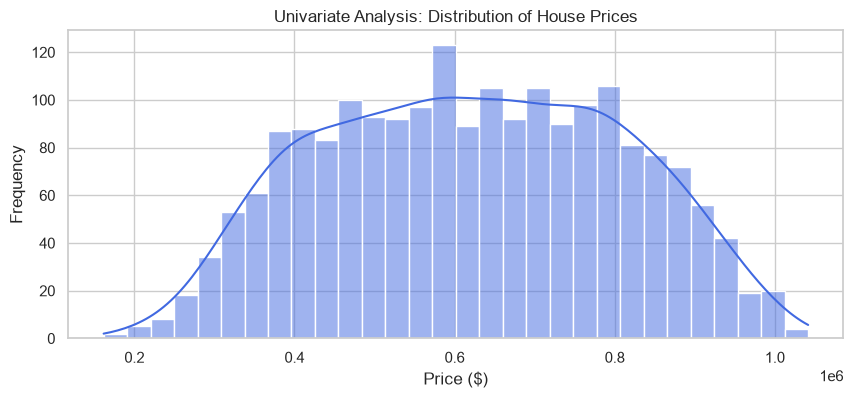

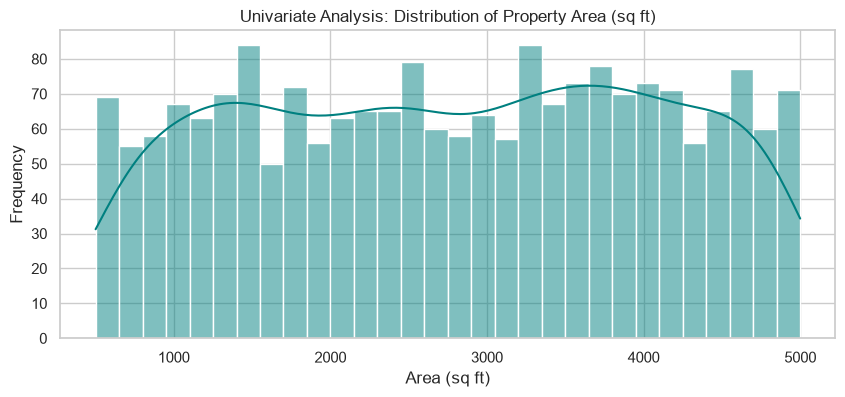

C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Location', data=df, ax=axes[0], palette='pastel')
C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Rural', 'Suburban', 'Urban', 'Downtown'])
C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Condition', data=df, ax=axes[1], palette='pastel')
C:\Users\Raj Krishna\AppData\Local\Temp

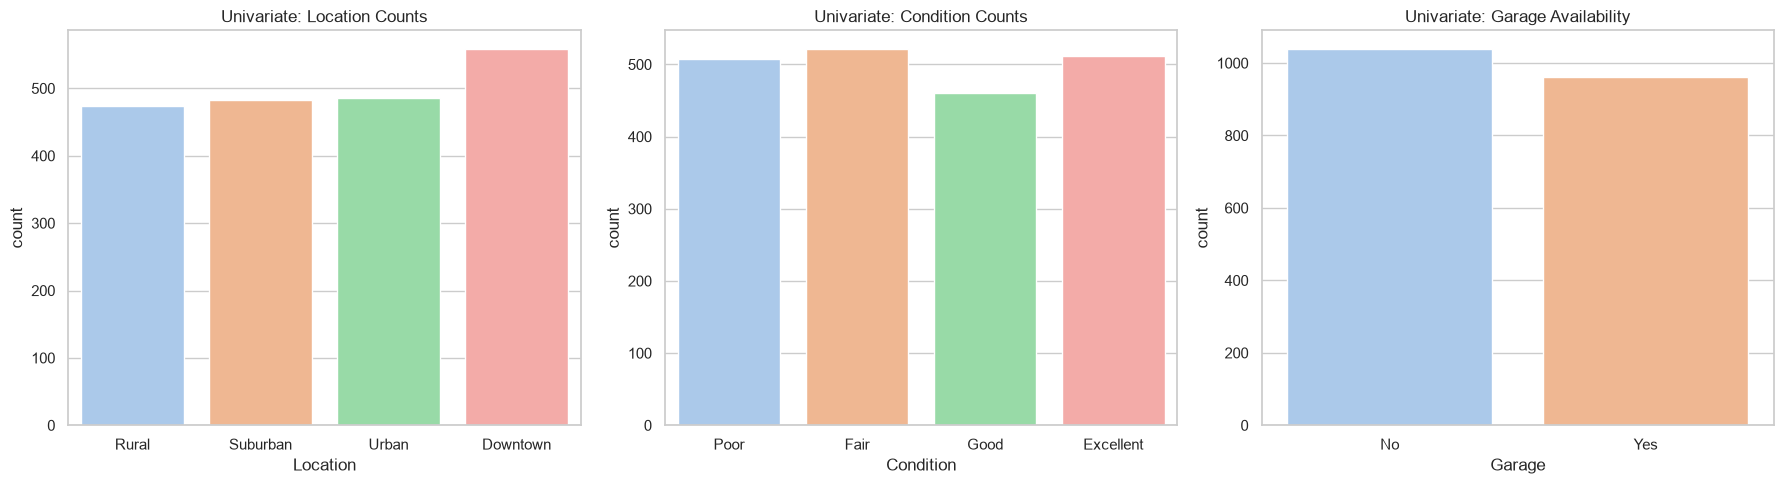

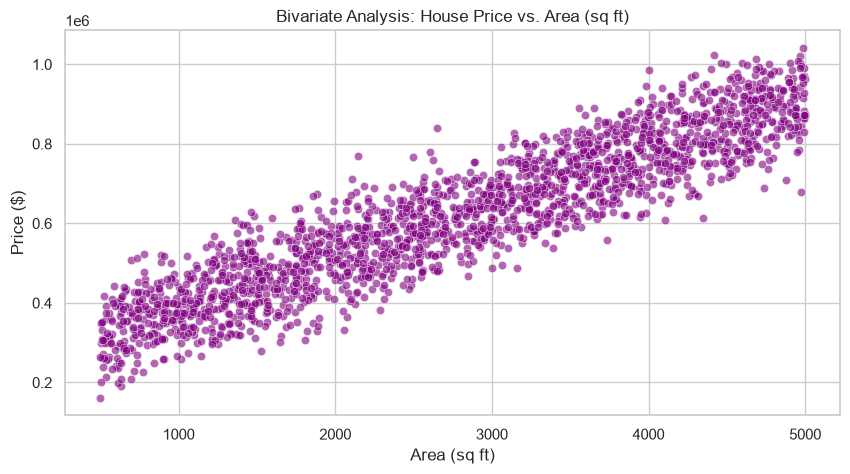

C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Location', y='Price', data=df, palette='Set2')


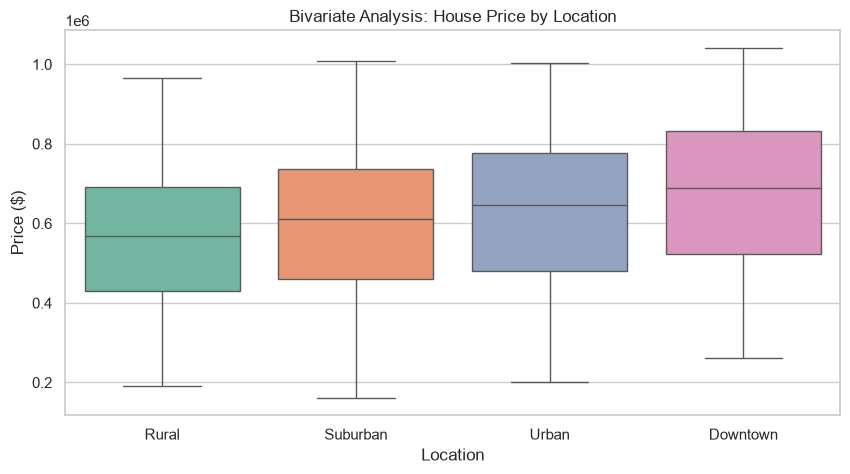

C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Price', data=df, palette='Set2')


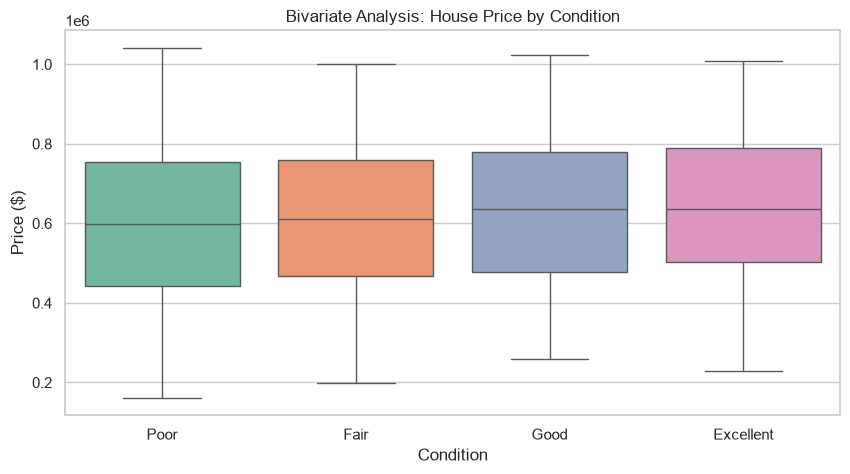

C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bedrooms', y='Price', data=df, ax=ax[0], palette='Blues')
C:\Users\Raj Krishna\AppData\Local\Temp\ipykernel_21872\1131378893.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Bathrooms', y='Price', data=df, ax=ax[1], palette='Oranges')


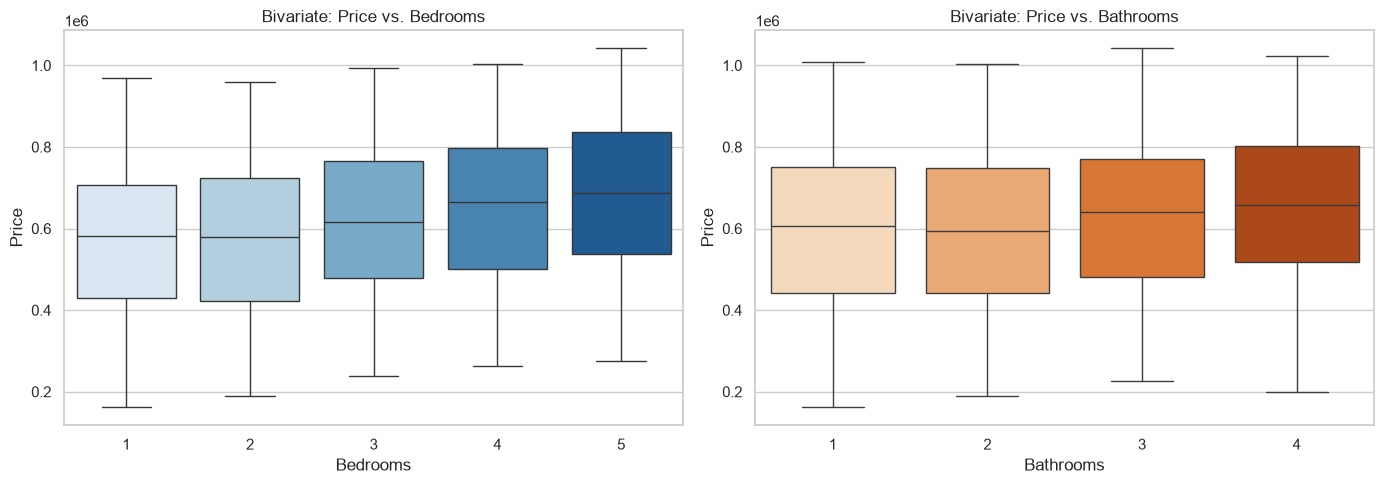

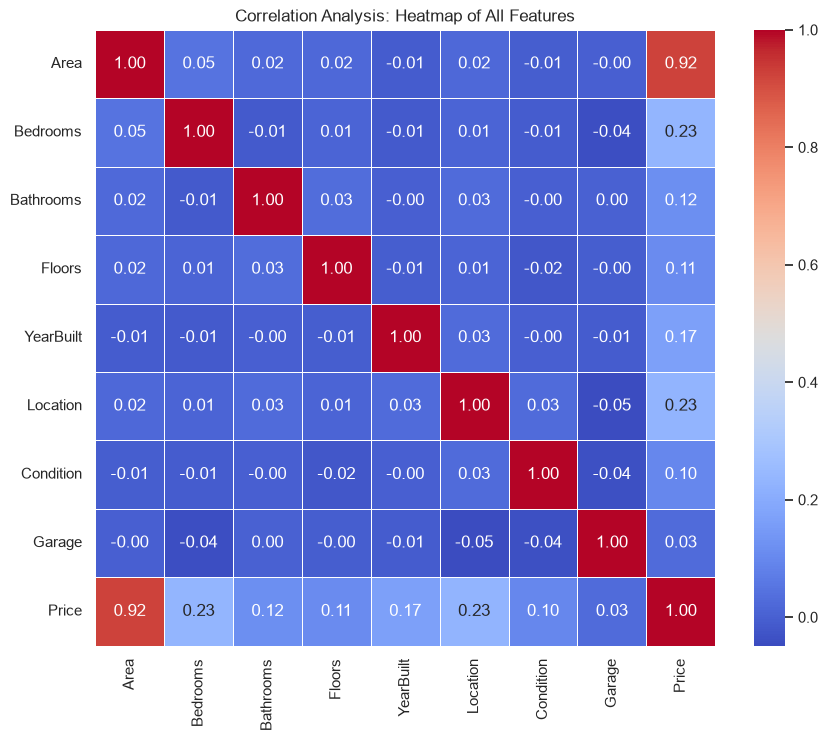

In [ ]:
 
# 3.1 UNIVARIATE ANALYSIS (Individual Distributions)

# 1. Histogram: Distribution of target variable 'Price'
plt.figure(figsize=(10, 4))
sns.histplot(df['Price'], kde=True, color='royalblue', bins=30)
plt.title('Univariate Analysis: Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# 2. Histogram: Distribution of continuous predictor 'Area'
plt.figure(figsize=(10, 4))
sns.histplot(df['Area'], kde=True, color='teal', bins=30)
plt.title('Univariate Analysis: Distribution of Property Area (sq ft)')
plt.xlabel('Area (sq ft)')
plt.ylabel('Frequency')
plt.show()

# 3. Count plots: Categorical counts (Location, Condition, Garage)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(x='Location', data=df, ax=axes[0], palette='pastel')
axes[0].set_title('Univariate: Location Counts')
axes[0].set_xticklabels(['Rural', 'Suburban', 'Urban', 'Downtown'])

sns.countplot(x='Condition', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Univariate: Condition Counts')
axes[1].set_xticklabels(['Poor', 'Fair', 'Good', 'Excellent'])

sns.countplot(x='Garage', data=df, ax=axes[2], palette='pastel')
axes[2].set_title('Univariate: Garage Availability')
axes[2].set_xticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()

# 3.2 BIVARIATE ANALYSIS (Predictors vs. Target)

# 1. Scatter Plot: Continuous variable (Area) vs. Target (Price)
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Area', y='Price', data=df, alpha=0.6, color='purple')
plt.title('Bivariate Analysis: House Price vs. Area (sq ft)')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.show()

# 2. Boxplot: Location vs. Target (Price)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Location', y='Price', data=df, palette='Set2')
plt.title('Bivariate Analysis: House Price by Location')
plt.xticks([0, 1, 2, 3], ['Rural', 'Suburban', 'Urban', 'Downtown'])
plt.xlabel('Location')
plt.ylabel('Price ($)')
plt.show()

# 3. Boxplot: Condition vs. Target (Price)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Condition', y='Price', data=df, palette='Set2')
plt.title('Bivariate Analysis: House Price by Condition')
plt.xticks([0, 1, 2, 3], ['Poor', 'Fair', 'Good', 'Excellent'])
plt.xlabel('Condition')
plt.ylabel('Price ($)')
plt.show()

# 4. Boxplots: Rooms vs. Price
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Bedrooms', y='Price', data=df, ax=ax[0], palette='Blues')
ax[0].set_title('Bivariate: Price vs. Bedrooms')
sns.boxplot(x='Bathrooms', y='Price', data=df, ax=ax[1], palette='Oranges')
ax[1].set_title('Bivariate: Price vs. Bathrooms')
plt.tight_layout()
plt.show()

# 3.3 CORRELATION ANALYSIS (Feature Heatmap)

# Heatmap: Visualizing the linear correlation coefficients of all features
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Analysis: Heatmap of All Features')
plt.show()

## 4. Phase 5: Feature Engineering

We calculate the dynamic `Property Age` column (relative to our current year 2026), drop the redundant `YearBuilt` column, and isolate the features ($X$) from the target ($y$).

In [4]:
# Convert YearBuilt to Property Age
CURRENT_YEAR = 2026
df['Property Age'] = CURRENT_YEAR - df['YearBuilt']
df = df.drop('YearBuilt', axis=1)

# Isolate features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

print("Final Model Features:")
print(X.columns.tolist())
print(f"X shape: {X.shape}, y shape: {y.shape}")

Final Model Features:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Location', 'Condition', 'Garage', 'Property Age']
X shape: (2000, 8), y shape: (2000,)


## 5. Phase 6: Model Building

We split the dataset into an 80/20 train-test ratio, build exactly three regression models (Linear Regression, Random Forest, XGBoost), and serialize them.

In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Initialize Models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit Models
print("Training Linear Regression...")
lr_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# Serialize Models to 'Model/' folder
os.makedirs('../Model', exist_ok=True)
joblib.dump(lr_model, '../Model/linear_regression.joblib')
joblib.dump(rf_model, '../Model/random_forest.joblib')
joblib.dump(xgb_model, '../Model/xgboost.joblib')
print("Models serialized successfully!")

Train size: 1600, Test size: 400
Training Linear Regression...
Training Random Forest...
Training XGBoost...
Models serialized successfully!


## 6. Phase 7: Model Evaluation

We evaluate all three models side-by-side using four metrics:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

In [6]:
# Predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return round(mae, 2), round(mse, 2), round(rmse, 2), round(r2, 4)

# Create comparison table
lr_metrics = evaluate_model(y_test, lr_preds)
rf_metrics = evaluate_model(y_test, rf_preds)
xgb_metrics = evaluate_model(y_test, xgb_preds)

evaluation_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
})
evaluation_df.set_index('Metric', inplace=True)
display(evaluation_df)

best_model = evaluation_df.loc['R² Score'].idxmax()
print(f"🏆 The Best Performing Model is: {best_model}")

,Linear Regression,Random Forest,XGBoost
Metric,,,
MAE,1.214120e+04,2.872399e+04,2.033194e+04
MSE,2.389851e+08,1.283659e+09,6.385023e+08
RMSE,1.545914e+04,3.582819e+04,2.526860e+04
R² Score,9.929000e-01,9.619000e-01,9.810000e-01


🏆 The Best Performing Model is: Linear Regression
